In [11]:
import sys
import warnings

warnings.filterwarnings('ignore')
sys.path.insert(0, '.')
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
from pathlib import Path

import config
from pipeline import data_prep, enrichment, plots, scoring
from pipeline.enrichment import gsea_run_dir, run_gsea_prerank
from pipeline.signatures import load_gsea
from viz_style import apply_style
apply_style()

In [12]:
dd = data_prep.load_disease_filtered() # Filter disease phenotype with OOD covariate distribution & too small samples sizes.
print(f'Final: {dd.Z_dis.shape[0]} samples, {len(np.unique(dd.dis_pheno))} phenotypes')

Final: 854 samples, 20 phenotypes


In [13]:
print(pd.Series(dd.dis_pheno).value_counts().to_string())

CAD_HF+ (Ward)                     112
Tuberculosis (Chang)               101
CAD_HF- (Ward)                     100
ME/CFS (Gardella)                   90
Pancreatitis (Moore)                79
Pancreatic Cancer (Moore)           72
Pre-eclampsia (Moufarrej)           59
Colorectal Cancer (Chen)            37
Lung Cancer (Chen)                  30
Liver Cancer (Roskams-Hieter)       28
Esophagus Cancer (Chen)             25
Stomach Cancer (Chen)               24
MM (Roskams-Hieter)                 17
Other Cancer (Moore)                16
HIV (Chang)                         13
ICI-m (Raissadati)                  11
ICI-treated Cancer (Raissadati)     11
HIV + Tuberculosis (Chang)          11
Liver Cancer (Chen)                 10
MGUS (Roskams-Hieter)                8


## GSEA conditions: which modeling stages/routes to include
Each condition selects a set of engine demotion-chain stages/routes; genes fit outside the set are zeroed in the ranking (`scoring.stage_masked_z`). No ubiquity/artifact filtering.
- **no_filter**: engine-only count routes (nbi + nb_fixed + intercept), rare(pool) excluded — the canonical baseline (dir name kept for gsea_compare / downstream compatibility).
- **with_rare**: nbi full-NBI genes + rare(pool) covariate GLM only.
- **nbi_only**: nbi full-NBI genes only.
Edit `CONDITIONS` to add/remove stages per run. Valid stages: 'nbi', 'nb_fixed', 'intercept', 'pool'.

In [19]:
# label -> set of engine stages/routes included in that run's ranking Z.
CONDITIONS = {
    'only_nbi_full':   ('nbi',),                            # full-NBI genes only
    'only_nbi':  ('nbi', 'nb_fixed', 'intercept'),   # engine-only count routes (no rare)
    'with_rare':  ('nbi', 'nb_fixed', 'intercept', 'pool'),                     # full-NBI genes + rare covariate GLM
}
for label, stages in CONDITIONS.items():
    print(f"{label:12s} stages={stages}  -> {gsea_run_dir(label).relative_to(config.ROOT)}")

only_nbi_full stages=('nbi',)  -> Modeling/GSEA/only_nbi_full
only_nbi     stages=('nbi', 'nb_fixed', 'intercept')  -> Modeling/GSEA/only_nbi
with_rare    stages=('nbi', 'nb_fixed', 'intercept', 'pool')  -> Modeling/GSEA/with_rare


## GSEA run — all conditions
Build each condition's stage-masked Z and run prerank (load if results already exist).

In [22]:
all_results = {}
unique_phenos = np.unique(dd.dis_pheno)

for label, stages in CONDITIONS.items():
    gdir = gsea_run_dir(label)
    existing = list(gdir.glob('gsea_result_*.csv'))
    if existing:
        print(f"[{label}] loading {len(existing)} files from {gdir.relative_to(config.ROOT)}")
        all_results[label] = {ph: load_gsea(ph, gsea_dir=gdir)
                              for ph in unique_phenos if load_gsea(ph, gsea_dir=gdir) is not None}
        continue
    Z = scoring.stage_masked_z(dd, stages)
    print(f"[{label}] running GSEA (stages={stages}) -> {gdir.relative_to(config.ROOT)}")
    all_results[label] = run_gsea_prerank(Z, dd.dis_pheno, dd.gene_syms, outdir=gdir, label=label)
    print(f"[{label}] done — {len(all_results[label])} phenotypes")

[only_nbi_full] loading 20 files from Modeling/GSEA/only_nbi_full
[only_nbi] loading 20 files from Modeling/GSEA/only_nbi
[with_rare] loading 20 files from Modeling/GSEA/with_rare


In [ ]:
sample_sizes = {ph: int((dd.dis_pheno == ph).sum()) for ph in unique_phenos}
for label in CONDITIONS:
    res = all_results.get(label, {})
    if not res:
        print(f"[{label}] no results — skipping plots"); continue
    fig_dir = gsea_run_dir(label) / 'Figures' / 'gsea_dotplot'
    print(f"[{label}] saving dotplots -> {fig_dir.relative_to(config.ROOT)}")
    plots.plot_gsea_dotplots(res, fig_dir=fig_dir, sample_sizes=sample_sizes)

## Artifact term counts per condition
Per condition: total significant GSEA terms, and how many are commonly-artifactual (histone/chromatin, ribosome/translation, mitochondria/OXPHOS).

In [23]:
import re

ARTIFACT_PATS = {
    'histone':  re.compile(r'histone|chromatin|nucleosome', re.I),
    'ribosome': re.compile(r'ribosom|rRNA|translation', re.I),
    'mito':     re.compile(r'mitochond|oxidative phosph|electron transport|respiratory chain', re.I),
}

rows = []
for label, res in all_results.items():
    terms = pd.concat(res.values())['Term'] if res else pd.Series([], dtype=str)
    row = {'condition': label, 'n_total': len(terms)}
    for cat, pat in ARTIFACT_PATS.items():
        row[cat] = int(terms.str.contains(pat, na=False).sum())
    rows.append(row)
artifact_counts = pd.DataFrame(rows).set_index('condition')
artifact_counts

,n_total,histone,ribosome,mito
condition,,,,
only_nbi_full,7123,110,536,311
only_nbi,10098,175,645,393
with_rare,11385,184,663,418


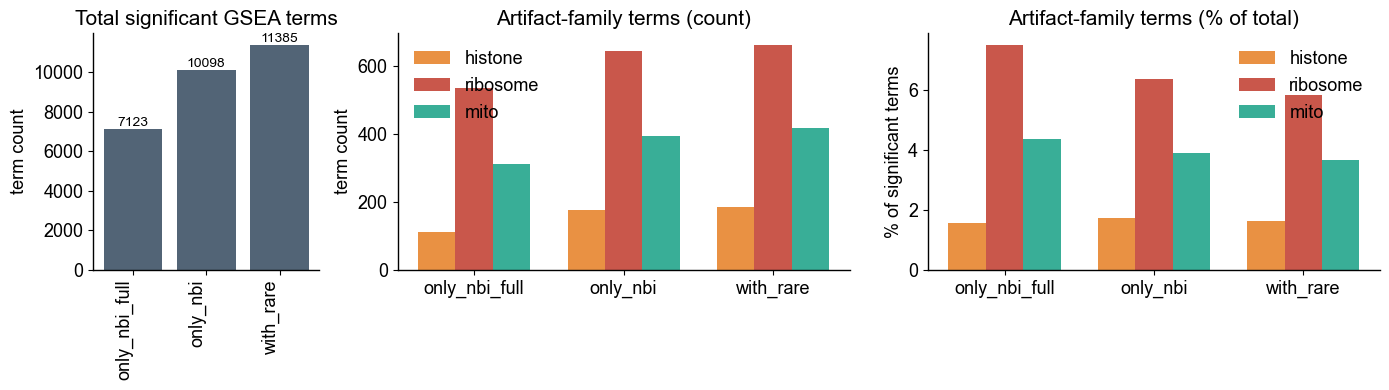

In [31]:
import matplotlib.pyplot as plt

conds = artifact_counts.index.tolist()
cats = ['histone', 'ribosome', 'mito']
colors = {'histone': '#e67e22', 'ribosome': '#c0392b', 'mito': '#16a085'}
pct = artifact_counts[cats].div(artifact_counts['n_total'].clip(lower=1), axis=0) * 100
fig, axes = plt.subplots(1, 3, figsize=(14, 4), width_ratios=(1, 2, 2))

# total significant terms per condition
axes[0].bar(conds, artifact_counts['n_total'], color='#34495e', alpha=0.85)
axes[0].set_title('Total significant GSEA terms')
axes[0].set_ylabel('term count'); axes[0].set_xticklabels(conds, rotation=90, ha='right')
for i, v in enumerate(artifact_counts['n_total']):
    axes[0].text(i, v, str(v), ha='center', va='bottom')

# artifact-family term counts, grouped by condition
x = np.arange(len(conds)); w = 0.25
for j, cat in enumerate(cats):
    axes[1].bar(x + (j - 1) * w, artifact_counts[cat], w, label=cat, color=colors[cat], alpha=0.85)
axes[1].set_xticks(x); axes[1].set_xticklabels(conds)
axes[1].set_title('Artifact-family terms (count)')
axes[1].set_ylabel('term count'); axes[1].legend(frameon=False)

# artifact-family terms as % of total significant terms
for j, cat in enumerate(cats):
    axes[2].bar(x + (j - 1) * w, pct[cat], w, label=cat, color=colors[cat], alpha=0.85)
axes[2].set_xticks(x); axes[2].set_xticklabels(conds)
axes[2].set_title('Artifact-family terms (% of total)')
axes[2].set_ylabel('% of significant terms'); axes[2].legend(frameon=False)

plt.tight_layout(); 
plt.savefig(config.GSEA_DIR / 'gsea_artifact_summary.png')